# Multivariate XGBoost Models
This notebook builds three XGBoost regression models using Malaysia air quality, electricity, and industrial production data. It includes log differencing, time-series splits, Granger causality tests, and SHAP explanations.

## 1. Load data and prepare variables
Load the cleaned dataset and extract the relevant input and output variables for the three models.

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor
import h5py
import shap

DATA_PATH = '../COS40007DataCleaning/combined_air_electricity_ipi_cleaned.csv'

def save_xgb_artifacts(model, prefix):
    model.save_model(f'{prefix}.json')
    raw = model.get_booster().save_raw()
    with h5py.File(f'{prefix}.h5', 'w') as f:
        f.create_dataset('xgb_booster_raw', data=np.frombuffer(raw, dtype=np.uint8))

# Load the dataset first, then inspect its head.
df = pd.read_csv(DATA_PATH, parse_dates=['date'])
print('Dataset shape:', df.shape)
df = df.sort_values('date').reset_index(drop=True)
print(df[['date', 'car_registration', 'electricity_local', 'ipi_abs_index', 'air_no2', 'air_so2', 'air_pm_25']].head())

Dataset shape: (60, 20)
        date  car_registration  electricity_local  ipi_abs_index  air_no2  \
0 2018-01-01             47162       11845.900250        113.447   0.0078   
1 2018-02-01             41705       11091.957006        101.820   0.0069   
2 2018-03-01             49810       12244.089947        112.270   0.0074   
3 2018-04-01             47834       12018.584577        108.986   0.0075   
4 2018-05-01             44598       12267.998390        111.631   0.0076   

   air_so2  air_pm_25  
0   0.0010      11.43  
1   0.0011      16.75  
2   0.0010      15.61  
3   0.0010      16.34  
4   0.0010      14.54  


## 2. Apply difference and log transformations
Apply time series transformations similar to the LSTM notebooks, including log transforms, differencing, and stationarity checks.

In [34]:
TEST_SIZE = 12

def preprocess_series(series, name):
    series = series.replace(0, np.nan).dropna()
    log_series = np.log(series)
    processed = log_series.copy()
    pvalue = adfuller(processed, autolag='AIC')[1]
    diff_order = 0
    if pvalue >= 0.05:
        processed = processed.diff().dropna()
        diff_order = 1
        pvalue = adfuller(processed, autolag='AIC')[1]
        if pvalue >= 0.05:
            processed = processed.diff().dropna()
            diff_order = 2
            pvalue = adfuller(processed, autolag='AIC')[1]
    print(f'{name}: log -> diff_order={diff_order}, adf_p={pvalue:.4f}, length={len(processed)}')
    return processed, diff_order


def invert_predicted_target(series_name, y_pred, y_test, diff_order, aligned_index):
    y_pred = np.asarray(y_pred).reshape(-1, 1)
    y_test = np.asarray(y_test).reshape(-1, 1)
    log_series = np.log(df.loc[aligned_index, series_name].replace(0, np.nan))

    if diff_order == 0:
        y_pred_log_values = y_pred
        y_test_log_values = y_test
    elif diff_order == 1:
        prev1 = log_series.iloc[-TEST_SIZE - 1:-1].values.reshape(-1, 1)
        y_pred_log_values = y_pred + prev1
        y_test_log_values = log_series.iloc[-TEST_SIZE:].values.reshape(-1, 1)
    else:
        prev1 = log_series.iloc[-TEST_SIZE - 1:-1].values.reshape(-1, 1)
        prev2 = log_series.iloc[-TEST_SIZE - 2:-2].values.reshape(-1, 1)
        y_pred_log_values = y_pred + 2 * prev1 - prev2
        y_test_log_values = log_series.iloc[-TEST_SIZE:].values.reshape(-1, 1)

    y_pred_original = np.exp(y_pred_log_values)
    y_test_original = np.exp(y_test_log_values)
    assert y_pred_original.shape == y_test_original.shape, \
        f"Shape mismatch! Preds: {y_pred_original.shape}, Actuals: {y_test_original.shape}"
    assert y_pred_original.shape[0] == TEST_SIZE, \
        f"Expected {TEST_SIZE} predictions, got {y_pred_original.shape[0]}"
    return y_pred_original.ravel(), y_test_original.ravel()


def print_original_scale_metrics(model_name, y_pred_orig, y_test_orig):
    mse_orig = mean_squared_error(y_test_orig, y_pred_orig)
    rmse_orig = np.sqrt(mse_orig)
    r2_orig = r2_score(y_test_orig, y_pred_orig)
    print(f'=== {model_name} metrics on original scale ===')
    print(f'  MSE : {mse_orig:.6f}')
    print(f'  RMSE: {rmse_orig:.6f}')
    print(f'  R2  : {r2_orig:.6f}')

processed = {}
processed_order = {}
for key, label in [
    ('car_registration', 'car_registration'),
    ('electricity_local', 'electricity_local'),
    ('ipi_abs_index', 'ipi_abs_index'),
    ('air_no2', 'air_no2'),
    ('air_so2', 'air_so2'),
    ('air_pm_25', 'air_pm_25')
]:
    processed[key], processed_order[key] = preprocess_series(df[key], label)

common_index = processed['air_no2'].index
for key in processed:
    processed[key] = processed[key].reindex(common_index)

processed_df = pd.DataFrame(processed).dropna()
print('Processed dataset shape:', processed_df.shape)
processed_df.head()

car_registration: log -> diff_order=0, adf_p=0.0000, length=60
electricity_local: log -> diff_order=0, adf_p=0.0004, length=60
ipi_abs_index: log -> diff_order=0, adf_p=0.0046, length=60
air_no2: log -> diff_order=0, adf_p=0.0315, length=60
air_so2: log -> diff_order=1, adf_p=0.0000, length=59
air_pm_25: log -> diff_order=0, adf_p=0.0041, length=60
Processed dataset shape: (59, 6)


,car_registration,electricity_local,ipi_abs_index,air_no2,air_so2,air_pm_25
1,10.638376,9.313976,4.623207,-4.976234,0.09531,2.818398
2,10.815971,9.412799,4.720907,-4.906275,-0.09531,2.747912
3,10.775492,9.394209,4.691219,-4.892852,0.00000,2.793616
4,10.705444,9.414749,4.715199,-4.879607,0.00000,2.676903
5,11.089195,9.368909,4.716738,-4.906275,0.09531,2.849550


## 3. Split data into training and test sets
Create chronological training and test splits. The last 12 observations are held out for testing.

In [35]:
train_df = processed_df.iloc[:-TEST_SIZE].copy()
test_df = processed_df.iloc[-TEST_SIZE:].copy()
print('Train shape:', train_df.shape)
print('Test shape:', test_df.shape)


Train shape: (47, 6)
Test shape: (12, 6)


## 4. Train XGBoost model for NO2
Model 1: inputs = Car Registrations + Electricity Local, output = NO2.

In [36]:
model1_features = ['car_registration', 'electricity_local']
model1_target = 'air_no2'

scaler1 = MinMaxScaler(feature_range=(0, 1))
X1_train = scaler1.fit_transform(train_df[model1_features])
X1_test = scaler1.transform(test_df[model1_features])
y1_train = train_df[model1_target].values
y1_test = test_df[model1_target].values

model1 = XGBRegressor(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
    objective='reg:squarederror',
    random_state=42,
    verbosity=0
)
model1.fit(X1_train, y1_train)
pred1 = model1.predict(X1_test)

print('Model 1 (NO2) evaluation - transformed scale:')
print('  RMSE:', np.sqrt(mean_squared_error(y1_test, pred1)))
print('  MAE :', mean_absolute_error(y1_test, pred1))
print('  R2  :', r2_score(y1_test, pred1))

y1_pred_orig, y1_test_orig = invert_predicted_target('air_no2', pred1, y1_test, processed_order['air_no2'], processed_df.index)
print_original_scale_metrics('Model 1 (NO2)', y1_pred_orig, y1_test_orig)

save_xgb_artifacts(model1, 'xgboost_model_air_no2_forecast')

Model 1 (NO2) evaluation - transformed scale:
  RMSE: 0.182959403515735
  MAE : 0.123282791899982
  R2  : -5.403079694231976
=== Model 1 (NO2) metrics on original scale ===
  MSE : 0.000002
  RMSE: 0.001301
  R2  : -8.000723


## 5. Train XGBoost model for SO2
Model 2: inputs = IPI Index + Electricity Local, output = SO2.

In [37]:
model2_features = ['ipi_abs_index', 'electricity_local']
model2_target = 'air_so2'

scaler2 = MinMaxScaler(feature_range=(0, 1))
X2_train = scaler2.fit_transform(train_df[model2_features])
X2_test = scaler2.transform(test_df[model2_features])
y2_train = train_df[model2_target].values
y2_test = test_df[model2_target].values

model2 = XGBRegressor(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
    objective='reg:squarederror',
    random_state=42,
    verbosity=0
)
model2.fit(X2_train, y2_train)
pred2 = model2.predict(X2_test)

print('Model 2 (SO2) evaluation - transformed scale:')
print('  RMSE:', np.sqrt(mean_squared_error(y2_test, pred2)))
print('  MAE :', mean_absolute_error(y2_test, pred2))
print('  R2  :', r2_score(y2_test, pred2))

y2_pred_orig, y2_test_orig = invert_predicted_target('air_so2', pred2, y2_test, processed_order['air_so2'], processed_df.index)
print_original_scale_metrics('Model 2 (SO2)', y2_pred_orig, y2_test_orig)

save_xgb_artifacts(model2, 'xgboost_model_air_so2_forecast')

Model 2 (SO2) evaluation - transformed scale:
  RMSE: 0.06909570585765196
  MAE : 0.04672194090754619
  R2  : -0.5845018904689496
=== Model 2 (SO2) metrics on original scale ===
  MSE : 0.000000
  RMSE: 0.000082
  R2  : -1.784987


## 6. Train XGBoost model for PM2.5
Model 3: input = NO2, output = PM2.5.

In [38]:
model3_features = ['air_no2']
model3_target = 'air_pm_25'

scaler3 = MinMaxScaler(feature_range=(0, 1))
X3_train = scaler3.fit_transform(train_df[model3_features])
X3_test = scaler3.transform(test_df[model3_features])
y3_train = train_df[model3_target].values
y3_test = test_df[model3_target].values

model3 = XGBRegressor(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
    objective='reg:squarederror',
    random_state=42,
    verbosity=0
)
model3.fit(X3_train, y3_train)
pred3 = model3.predict(X3_test)

print('Model 3 (PM2.5) evaluation - transformed scale:')
print('  RMSE:', np.sqrt(mean_squared_error(y3_test, pred3)))
print('  MAE :', mean_absolute_error(y3_test, pred3))
print('  R2  :', r2_score(y3_test, pred3))

y3_pred_orig, y3_test_orig = invert_predicted_target('air_pm_25', pred3, y3_test, processed_order['air_pm_25'], processed_df.index)
print_original_scale_metrics('Model 3 (PM2.5)', y3_pred_orig, y3_test_orig)

save_xgb_artifacts(model3, 'xgboost_model_pm25_forecast')

Model 3 (PM2.5) evaluation - transformed scale:
  RMSE: 0.15836135010277785
  MAE : 0.13242190415336105
  R2  : -0.9446054188292203
=== Model 3 (PM2.5) metrics on original scale ===
  MSE : 3.833767
  RMSE: 1.958001
  R2  : -0.979800


## 7. Evaluate Granger causality relationships
Test whether input series help predict each target series.

In [39]:
# Build residual series from the test set predictions
residuals_df = pd.DataFrame({
    'residual_no2': pd.Series(y1_test - pred1, index=test_df.index),
    'residual_so2': pd.Series(y2_test - pred2, index=test_df.index),
    'residual_pm_25': pd.Series(y3_test - pred3, index=test_df.index),
    'car_registration': test_df['car_registration'],
    'electricity_local': test_df['electricity_local'],
    'ipi_abs_index': test_df['ipi_abs_index'],
    'air_no2': test_df['air_no2']
})

print('Residuals dataset shape:', residuals_df.shape)
print(residuals_df.head())


def granger_causality_results(df_in, target, causes, maxlag=4):
    results = {}
    for cause in causes:
        series = df_in[[target, cause]].dropna()
        n_obs = len(series)
        
        # Calculate the safe maximum lag based on the statsmodels requirement
        # (x.shape[0] - constant) / 3 - 1
        safe_maxlag = int((n_obs - 1) / 3) - 1
        
        # Use the smaller of the requested maxlag or the safe limit
        effective_maxlag = min(maxlag, safe_maxlag)
        
        if effective_maxlag < 1:
            results[cause] = None
            continue
            
        try:
            tests = grangercausalitytests(series[[target, cause]], maxlag=effective_maxlag, verbose=False)
            results[cause] = {lag: round(tests[lag][0]['ssr_ftest'][1], 4) for lag in range(1, effective_maxlag + 1)}
        except Exception:
            results[cause] = None
    return results


def format_pvalue(p):
    if p < 0.01: return f"{p:.4f} ***"
    if p < 0.05: return f"{p:.4f} **"
    if p < 0.10: return f"{p:.4f}  *"
    return f"{p:.4f}"


def get_granger_df(df_in, target, causes, maxlag=4):
    raw_results = granger_causality_results(df_in, target, causes, maxlag=maxlag)
    
    rows = []
    for cause, lag_pvals in raw_results.items():
        if lag_pvals is None:
            rows.append({'Cause': cause, 'Min p-value': None, 'Best lag': None})
            continue
        best_lag = min(lag_pvals, key=lag_pvals.get)
        min_p = lag_pvals[best_lag]
        rows.append({'Cause': cause, 'Min p-value': min_p, 'Best lag': best_lag})
    
    results_df = pd.DataFrame(rows).set_index('Cause')
    results_df['Min p-value'] = results_df['Min p-value'].map(format_pvalue)
    return results_df


models = [
    ('Model 1: NO2 residuals',   'residual_no2',   ['car_registration', 'electricity_local']),
    ('Model 2: SO2 residuals',   'residual_so2',   ['ipi_abs_index',    'electricity_local']),
    ('Model 3: PM2.5 residuals', 'residual_pm_25', ['air_no2']),
]

SIGNIFICANCE = "*** p<0.01   ** p<0.05   * p<0.10"

for title, target, causes in models:
    print(f"\n{'─' * 52}")
    print(f"  {title}  │  target: {target}")
    print(f"{'─' * 52}")
    df = get_granger_df(residuals_df, target, causes)
    print(df.to_string())

print(f"\n{SIGNIFICANCE}")


Residuals dataset shape: (12, 7)
    residual_no2  residual_so2  residual_pm_25  car_registration  \
48     -0.002438     -0.017897        0.166408         10.704749   
49     -0.228100     -0.175032       -0.291844         10.738568   
50     -0.430691      0.085714       -0.012513         11.203856   
51      0.013048      0.065934        0.046471         11.024024   
52     -0.095809     -0.021713        0.096808         10.876801   

    electricity_local  ipi_abs_index   air_no2  
48           9.467802       4.827233 -5.099467  
49           9.384228       4.757393 -5.259097  
50           9.491914       4.841033 -5.149897  
51           9.482820       4.791459 -4.990833  
52           9.492126       4.782747 -5.035953  

────────────────────────────────────────────────────
  Model 1: NO2 residuals  │  target: residual_no2
────────────────────────────────────────────────────
                  Min p-value  Best lag
Cause                                  
car_registration       0.21

## 8. Compute SHAP feature importance for each model
Use SHAP to explain model predictions and rank feature importance for the XGBoost models.

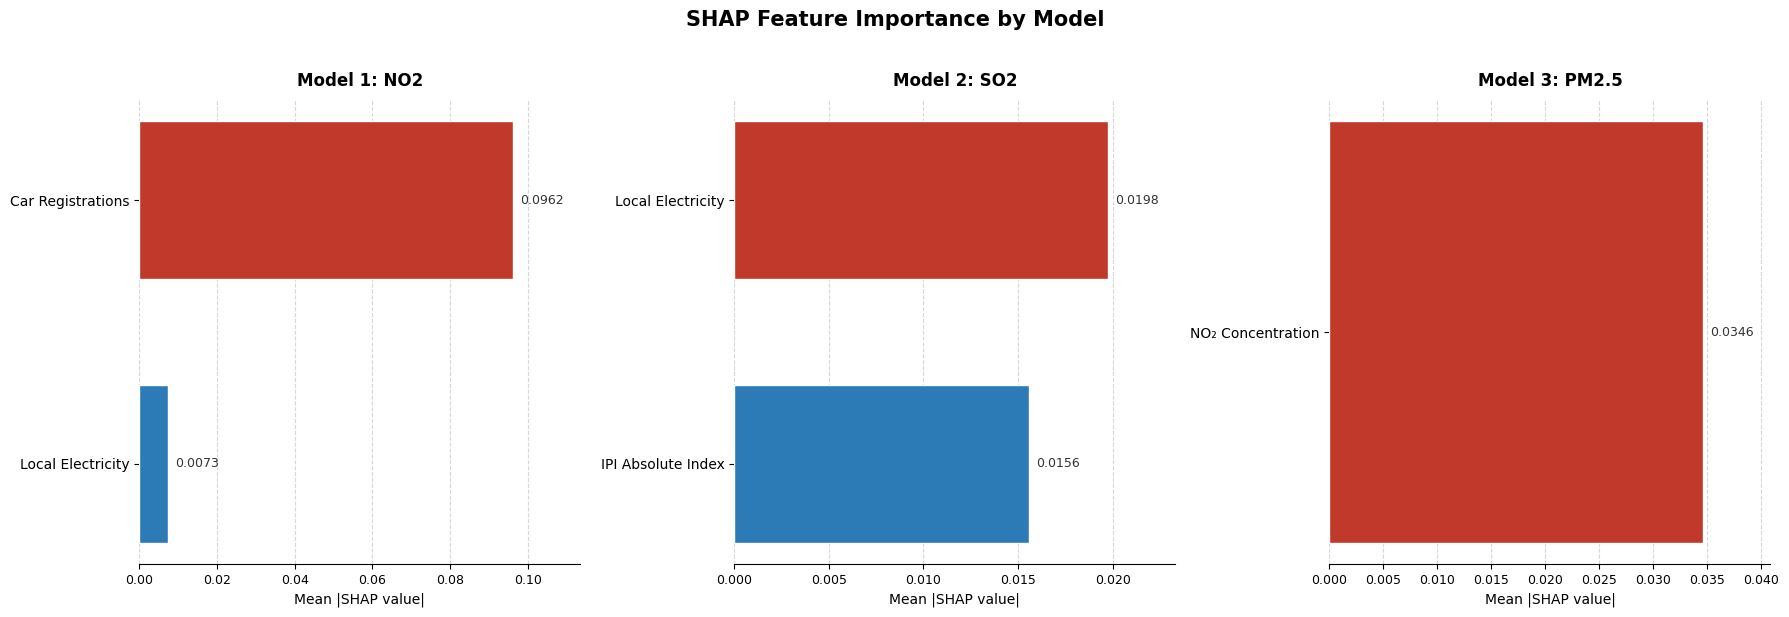

In [40]:
models_config = [
    ('Model 1: NO2',   model1, X1_test),
    ('Model 2: SO2',   model2, X2_test),
    ('Model 3: PM2.5', model3, X3_test),
]

FEATURE_MAP = {
    'Model 1: NO2': ['car_registration', 'electricity_local'],
    'Model 2: SO2': ['ipi_abs_index', 'electricity_local'],
    'Model 3: PM2.5': ['air_no2'] 
}

FEATURE_NAMES = {
    'car_registration':  'Car Registrations',
    'electricity_local': 'Local Electricity',
    'ipi_abs_index':     'IPI Absolute Index',
    'air_no2':           'NO₂ Concentration',
    'air_so2':           'SO₂ Concentration',
    'air_pm_25':         'PM2.5 Concentration',
}

FEATURE_COLS = [
    'car_registration',
    'electricity_local',
    'ipi_abs_index',
    'air_no2',
    'air_so2',
    'air_pm_25'
]


def rename_columns(df):
    return df.rename(columns={c: FEATURE_NAMES.get(c, c) for c in df.columns})

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('SHAP Feature Importance by Model', fontsize=15, fontweight='bold', y=1.02)

for ax, (title, model, X_test) in zip(axes, models_config):
    model_key = title 
    current_cols = FEATURE_MAP.get(model_key, FEATURE_COLS) 
    
    # Now create the DataFrame with the correct number of columns
    X_test_df = pd.DataFrame(X_test, columns=current_cols)
    
    # Rename as usual
    X_named = rename_columns(X_test_df)
    
    explainer = shap.Explainer(model, X_named)
    shap_values = explainer(X_named)
    
    # Mean absolute SHAP per feature
    mean_shap = np.abs(shap_values.values).mean(axis=0)
    feat_names = X_named.columns.tolist()
    
    order = np.argsort(mean_shap)
    sorted_names = [feat_names[i] for i in order]
    sorted_vals  = mean_shap[order]
    
    colors = ['#c0392b' if v == sorted_vals.max() else '#2c7bb6' for v in sorted_vals]
    
    bars = ax.barh(sorted_names, sorted_vals, color=colors, edgecolor='white', height=0.6)
    
    for bar, val in zip(bars, sorted_vals):
        ax.text(val + sorted_vals.max() * 0.02, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', ha='left', fontsize=9, color='#333333')
    
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Mean |SHAP value|', fontsize=10)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.tick_params(axis='y', labelsize=10)
    ax.tick_params(axis='x', labelsize=9)
    ax.xaxis.grid(True, linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)
    ax.margins(x=0.18)

plt.tight_layout()
plt.show()